# MacSentinel 06 · Adversarial Robustness & Drift

## tl;dr

A detector that looks strong on an ordinary holdout can degrade under benign software rollouts or attacker mimicry. This notebook measures that degradation and converts privacy, recall, false-positive, and drift requirements into release gates.

## Goal

Stress-test MacSentinel against concept drift and mimicry attacks before treating benchmark performance as deployment readiness.

**Safety and scope:** all events are deterministic synthetic fixtures. Reserved `.example` domains and inert filenames are used; this project does not execute payloads, collect private data, or bypass platform controls.


## Setup

Load the shared synthetic macOS telemetry fixture and dependency-light visualization helpers. The data source and seed are explicit so every result can be reproduced offline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from macsentinel.core import *
from macsentinel.visuals import *

SEED = 42
DATA_PATH = Path("data/synthetic_macos_events.csv")
events = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FIGURES = []
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Loaded {len(events):,} synthetic events across {events.session_id.nunique():,} sessions and {events.host_id.nunique()} hosts.")


Loaded 2,520 synthetic events across 420 sessions and 30 hosts.


## Steps

### 1. Train a baseline detector on original telemetry


In [2]:
baseline_sessions = aggregate_sessions(events)
train_index, test_index = group_train_test_split(baseline_sessions, test_fraction=0.30)
features = baseline_sessions[FEATURE_COLUMNS].to_numpy()
labels = baseline_sessions.label.to_numpy()
model = fit_logistic(features[train_index], labels[train_index], FEATURE_COLUMNS)
test_ids = baseline_sessions.iloc[test_index].session_id.tolist()
baseline_scores = predict_logistic(model, features[test_index])
baseline_metrics = evaluate_scores(labels[test_index], baseline_scores, 0.50)
print(pd.Series(baseline_metrics).round(4).to_string())


precision             0.7000
recall                0.9545
f1                    0.8077
accuracy              0.9187
tp                   21.0000
fp                    9.0000
tn                   92.0000
fn                    1.0000
average_precision     0.9687
threshold             0.5000
alert_rate            0.2439


### 2. Create benign concept drift and attacker mimicry stress sets


In [3]:
drift_events = apply_concept_drift(events)
mimicry_events = apply_mimicry_attack(events)
drift_sessions = aggregate_sessions(drift_events).set_index("session_id").loc[test_ids].reset_index()
mimicry_sessions = aggregate_sessions(mimicry_events).set_index("session_id").loc[test_ids].reset_index()

drift_scores = predict_logistic(model, drift_sessions[FEATURE_COLUMNS].to_numpy())
mimicry_scores = predict_logistic(model, mimicry_sessions[FEATURE_COLUMNS].to_numpy())
drift_metrics = evaluate_scores(drift_sessions.label.to_numpy(), drift_scores, 0.50)
mimicry_metrics = evaluate_scores(mimicry_sessions.label.to_numpy(), mimicry_scores, 0.50)

evaluation = pd.DataFrame([baseline_metrics, drift_metrics, mimicry_metrics], index=["baseline", "benign concept drift", "attacker mimicry"])
evaluation["false_positive_rate"] = evaluation.fp / (evaluation.fp + evaluation.tn).clip(lower=1)
print(evaluation[["precision", "recall", "f1", "average_precision", "false_positive_rate", "alert_rate"]].round(3).to_string())


                      precision  recall     f1  average_precision  false_positive_rate  alert_rate
baseline                  0.700   0.955  0.808              0.969                0.089       0.244
benign concept drift      0.840   0.955  0.894              0.989                0.040       0.203
attacker mimicry          0.182   0.091  0.121              0.385                0.089       0.089


## Visual Insights & ML Extension

### 3. Compare robustness outcomes


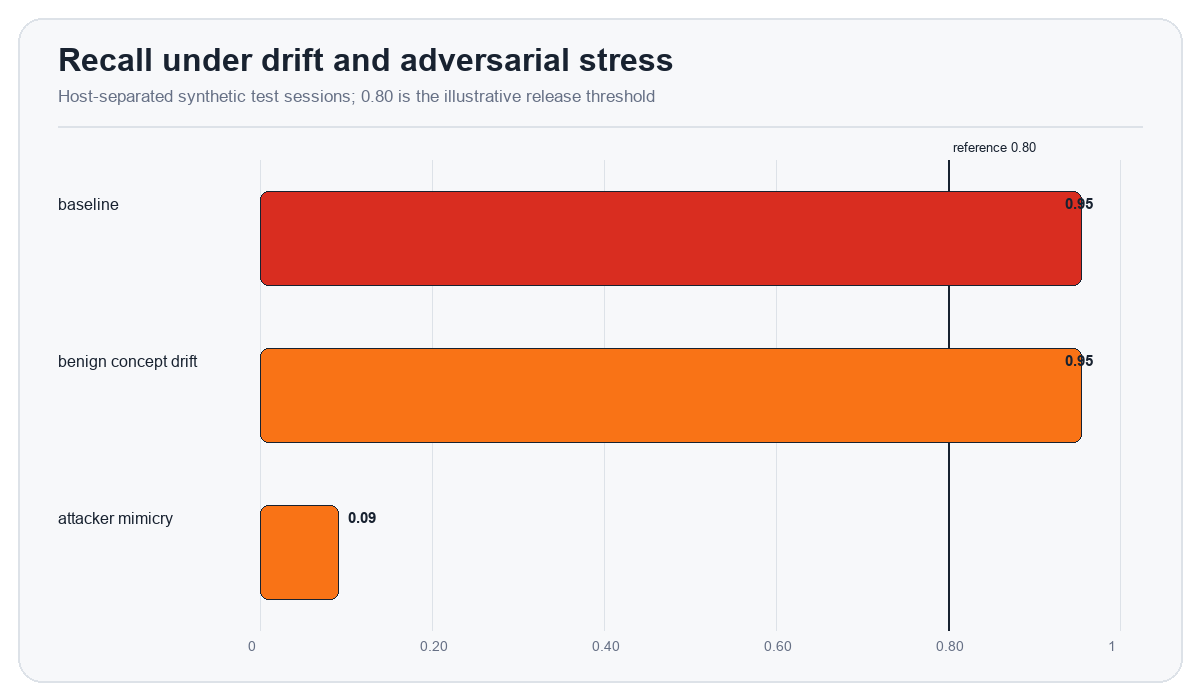

In [4]:
figure = bar_chart(
    evaluation.index,
    evaluation.recall,
    "Recall under drift and adversarial stress",
    "Host-separated synthetic test sessions; 0.80 is the illustrative release threshold",
    color=ORANGE,
    benchmark=0.80,
)
FIGURES.append(figure)
figure


### 4. Quantify feature drift


log1p_bytes_out               0.374
rare_process_ratio            0.082
unsigned_ratio                0.000
not_notarized_ratio           0.000
gatekeeper_bypass_count       0.000
xprotect_detection_count      0.000
privilege_escalation_count    0.000
persistence_write_count       0.000
sensitive_access_count        0.000
network_beacon_count          0.000
max_file_write_count          0.000


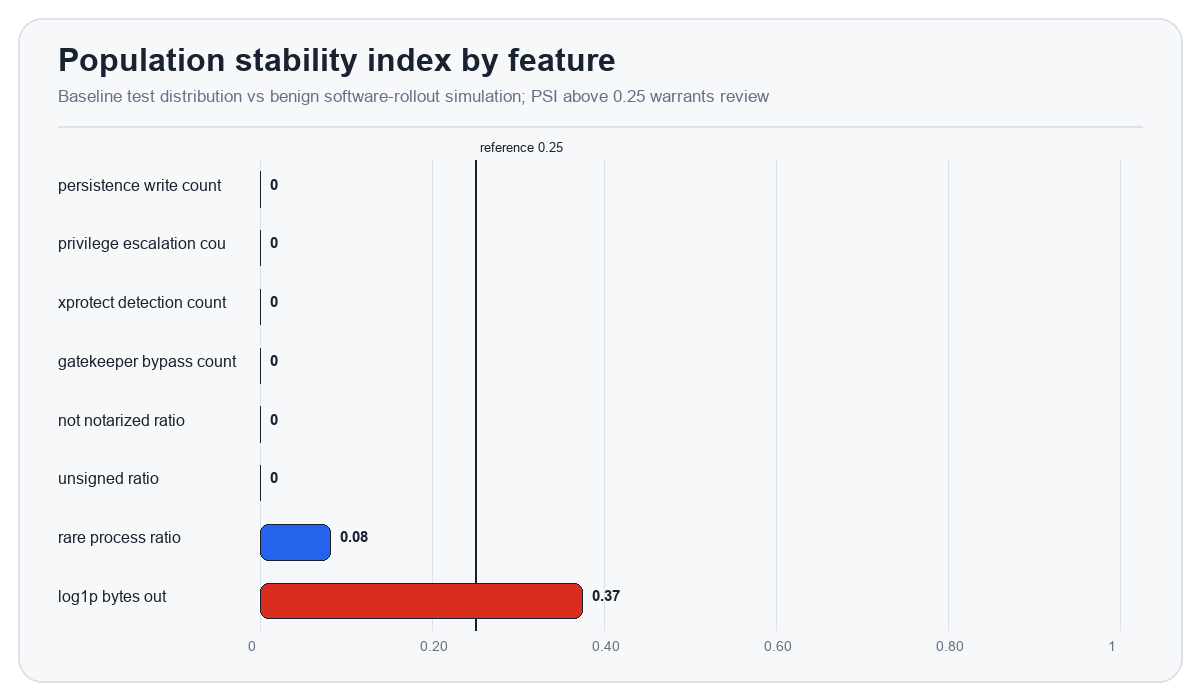

In [5]:
reference = baseline_sessions.iloc[test_index]
psi = pd.Series({
    feature: population_stability_index(reference[feature].to_numpy(), drift_sessions[feature].to_numpy())
    for feature in FEATURE_COLUMNS
}).sort_values(ascending=False)
print(psi.round(3).to_string())
figure = bar_chart(
    psi.head(8).index[::-1], psi.head(8).values[::-1],
    "Population stability index by feature",
    "Baseline test distribution vs benign software-rollout simulation; PSI above 0.25 warrants review",
    color=BLUE,
    benchmark=0.25,
)
FIGURES.append(figure)
figure


### 5. Define production-style release gates


In [6]:
privacy_fields = {"event_id", "timestamp", "host_id", "user_hash", "session_id", "process", "event_type", "target"}
forbidden_content_fields = {"file_contents", "clipboard_contents", "message_body", "password", "secret"}
release_gates = pd.DataFrame([
    {"gate": "baseline recall ≥ 0.80", "value": baseline_metrics["recall"], "pass": baseline_metrics["recall"] >= 0.80},
    {"gate": "mimicry recall ≥ 0.65", "value": mimicry_metrics["recall"], "pass": mimicry_metrics["recall"] >= 0.65},
    {"gate": "drift false-positive rate ≤ 0.08", "value": evaluation.loc["benign concept drift", "false_positive_rate"], "pass": evaluation.loc["benign concept drift", "false_positive_rate"] <= 0.08},
    {"gate": "maximum PSI ≤ 0.25", "value": psi.max(), "pass": psi.max() <= 0.25},
    {"gate": "no content collection", "value": float(forbidden_content_fields.isdisjoint(events.columns)), "pass": forbidden_content_fields.isdisjoint(events.columns)},
])
print(release_gates.to_string(index=False, formatters={"value": "{:.3f}".format}))


                            gate value  pass
          baseline recall ≥ 0.80 0.955  True
           mimicry recall ≥ 0.65 0.091 False
drift false-positive rate ≤ 0.08 0.040  True
              maximum PSI ≤ 0.25 0.374 False
           no content collection 1.000  True


## Checks


In [7]:
assert baseline_sessions.session_id.tolist() == aggregate_sessions(events).session_id.tolist()
assert set(reference.session_id) == set(drift_sessions.session_id) == set(mimicry_sessions.session_id)
assert forbidden_content_fields.isdisjoint(events.columns)
assert evaluation.loc["attacker mimicry", "recall"] <= evaluation.loc["baseline", "recall"]
print("PASS: aligned stress populations, privacy schema, and expected mimicry degradation are valid.")


PASS: aligned stress populations, privacy schema, and expected mimicry degradation are valid.


## Next Steps

- Block release when robustness or privacy gates fail; do not average them away.
- Retrain only after verifying that drift reflects legitimate product change rather than compromise.
- Add latency, memory, model-signing, rollback, and human-override gates for Apple-silicon deployment.
